# Electromechanical System Identification - MetaMSS

Example created by Wilson Rocha Lacerda Junior

> **Looking for more details on NARMAX models?**
> For comprehensive information on models, methods, and a wide range of examples and benchmarks implemented in SysIdentPy, check out our book:
> [*Nonlinear System Identification and Forecasting: Theory and Practice With SysIdentPy*](https://sysidentpy.org/book/0%20-%20Preface/)
>
> This book provides in-depth guidance to support your work with SysIdentPy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sysidentpy.model_structure_selection import MetaMSS, FROLS
from sysidentpy.metrics import root_relative_squared_error
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation import RecursiveLeastSquares
from sysidentpy.utils.display_results import results
from sysidentpy.utils.plotting import plot_residues_correlation, plot_results
from sysidentpy.residues.residues_correlation import (
    compute_residues_autocorrelation,
    compute_cross_correlation,
)


<Axes: >

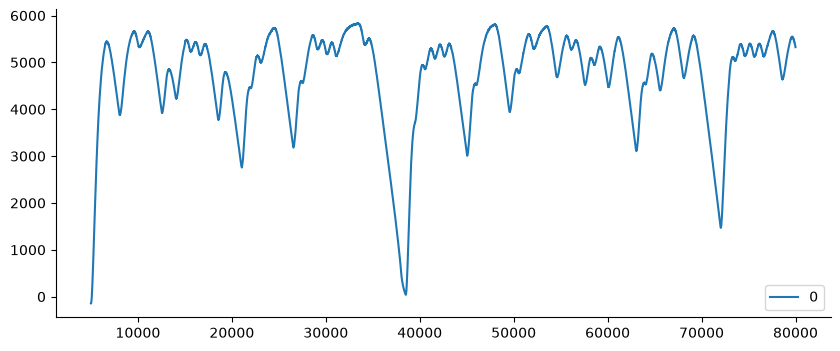

In [2]:
data_url = (
    "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/"
    "4085901293ba5ed5674bb2911ef4d1fa20f3438d/datasets/generator/"
)
df1 = pd.read_csv(f"{data_url}x_cc.csv", header=None)
df2 = pd.read_csv(f"{data_url}y_cc.csv", header=None)

df2[5000:80000].plot(figsize=(10, 4))


In [3]:
df1.iloc[::500].values.shape


(1000, 1)

We decimate the data by a factor of 500 and split the resulting 1,000 samples into equal training and test sets. MetaMSS performs its own train-validation split while searching for the model structure.

The input and output scalers are fitted exclusively on the training set. All models operate on standardized data, but predictions are converted back to the original output unit before plotting, residual analysis, and metric evaluation.

The table below isolates the effect of scaling and the RLS forgetting factor on MetaMSS with `random_state=42`. Both RRSE values exclude the first `max_lag` samples.

| Preprocessing | RLS `lam` | Free-run RRSE | One-step-ahead RRSE |
|---|---:|---:|---:|
| No scaling | 0.98 | 2.184406 | 0.037653 |
| Train-only scaling | 0.98 | 0.035944 | 0.021008 |
| Train-only scaling | 0.95 | 0.031354 | 0.022595 |

The remainder of this notebook uses train-only scaling and `lam=0.95`.

In [4]:
# We decimate the data using d=500 in this example.
x_train, x_test = np.split(df1.iloc[::500].values, 2)
y_train, y_test = np.split(df2.iloc[::500].values, 2)

x_scaler = StandardScaler()
y_scaler = StandardScaler()
x_train_scaled = x_scaler.fit_transform(x_train)
x_test_scaled = x_scaler.transform(x_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)


In [5]:
basis_function = Polynomial(degree=2)
estimator = RecursiveLeastSquares(lam=0.95, delta=0.01)

model = MetaMSS(
    xlag=5,
    ylag=5,
    estimator=estimator,
    maxiter=5,
    n_agents=15,
    basis_function=basis_function,
    random_state=42,
)

with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
    model.fit(X=x_train_scaled, y=y_train_scaled)


Free-run RRSE: 0.031354
One-step-ahead RRSE: 0.022595
        Regressors   Parameters             ERR
0           y(k-1)   7.0968E-01  0.00000000E+00
1           y(k-3)  -5.8259E-02  0.00000000E+00
2           y(k-4)  -1.0981E-04  0.00000000E+00
3          x1(k-1)   3.7458E-01  0.00000000E+00
4          x1(k-4)   2.2133E-01  0.00000000E+00
5         y(k-1)^2  -2.2259E-02  0.00000000E+00
6     y(k-2)y(k-1)   1.3530E-02  0.00000000E+00
7     y(k-3)y(k-1)   1.6170E-02  0.00000000E+00
8     y(k-4)y(k-1)  -2.0950E-02  0.00000000E+00
9     y(k-5)y(k-1)  -5.9322E-03  0.00000000E+00
10   x1(k-1)y(k-1)  -4.1207E-01  0.00000000E+00
11   x1(k-2)y(k-1)  -1.6460E-01  0.00000000E+00
12    y(k-4)y(k-2)   1.0074E-02  0.00000000E+00
13    y(k-5)y(k-2)   1.4187E-02  0.00000000E+00
14   x1(k-1)y(k-2)   2.8701E-01  0.00000000E+00
15   x1(k-3)y(k-2)   3.5765E-03  0.00000000E+00
16        y(k-3)^2  -1.2085E-02  0.00000000E+00
17    y(k-4)y(k-3)   8.3141E-03  0.00000000E+00
18   x1(k-1)y(k-3)  -1.2719E-01  0

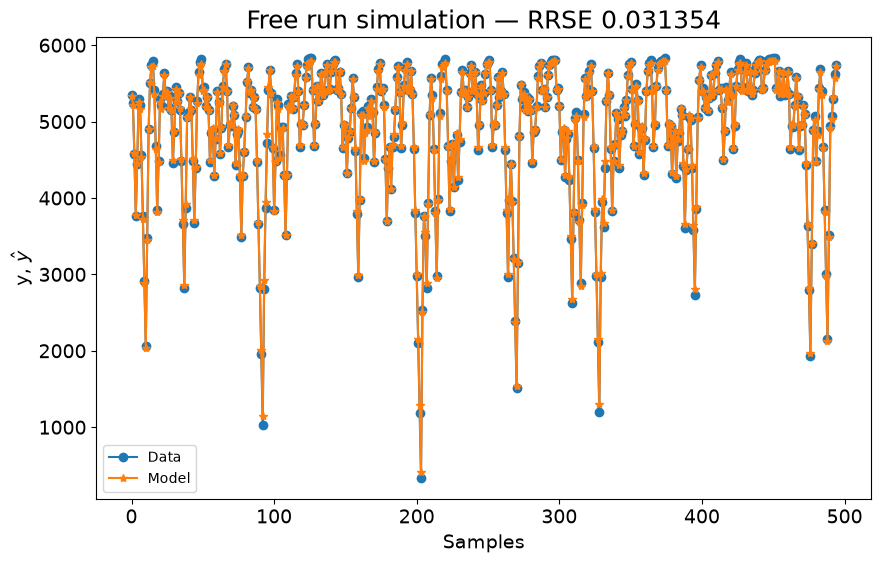

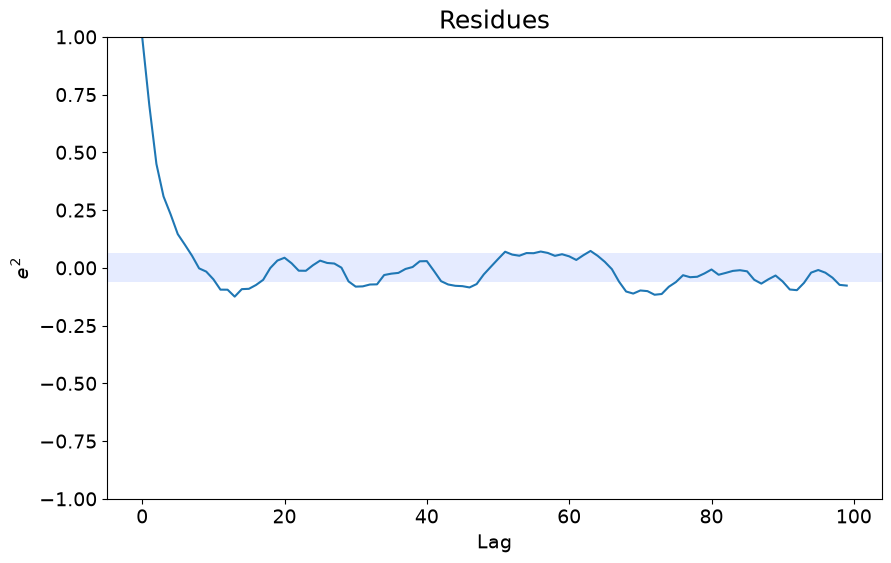

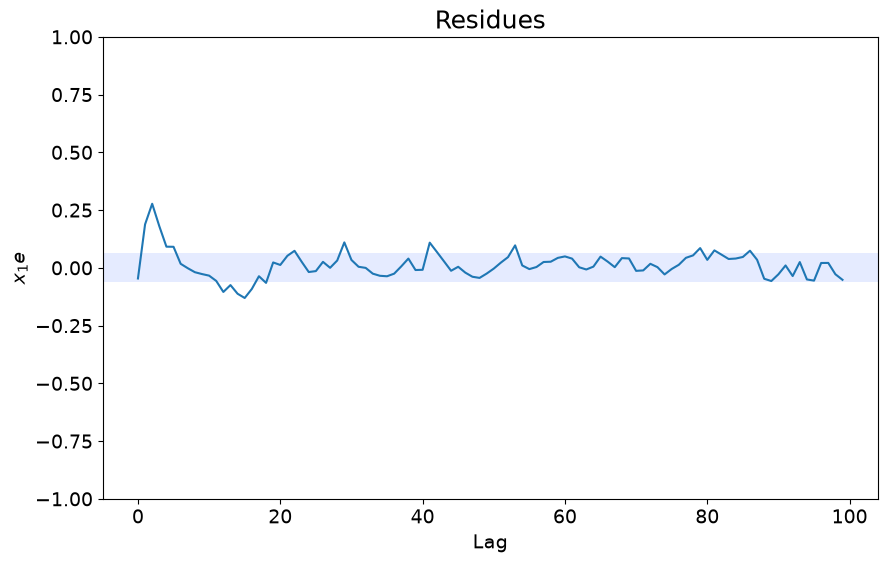

In [6]:
yhat_free_scaled = model.predict(
    X=x_test_scaled, y=y_test_scaled, steps_ahead=None
)
yhat_one_step_scaled = model.predict(
    X=x_test_scaled, y=y_test_scaled, steps_ahead=1
)

yhat_free = y_scaler.inverse_transform(yhat_free_scaled)
yhat_one_step = y_scaler.inverse_transform(yhat_one_step_scaled)

if not (np.isfinite(yhat_free).all() and np.isfinite(yhat_one_step).all()):
    raise RuntimeError("The selected model produced a non-finite prediction.")

start = model.max_lag
y_eval = y_test[start:]
yhat_free_eval = yhat_free[start:]
yhat_one_step_eval = yhat_one_step[start:]
x_eval = x_test[start:]

rrse_free = root_relative_squared_error(y_eval, yhat_free_eval)
rrse_one_step = root_relative_squared_error(y_eval, yhat_one_step_eval)
print(f"Free-run RRSE: {rrse_free:.6f}")
print(f"One-step-ahead RRSE: {rrse_one_step:.6f}")

r = pd.DataFrame(
    results(
        model.final_model,
        model.theta,
        model.err,
        model.n_terms,
        err_precision=8,
        dtype="sci",
    ),
    columns=["Regressors", "Parameters", "ERR"],
)
print(r)

plot_results(
    y=y_eval,
    yhat=yhat_free_eval,
    n=1000,
    title=f"Free run simulation — RRSE {rrse_free:.6f}",
)
ee = compute_residues_autocorrelation(y_eval, yhat_free_eval)
plot_residues_correlation(data=ee, title="Residues", ylabel="$e^2$")
x1e = compute_cross_correlation(y_eval, yhat_free_eval, x_eval)
plot_residues_correlation(data=x1e, title="Residues", ylabel="$x_1e$")


np.float64(0.0019710527273242157)

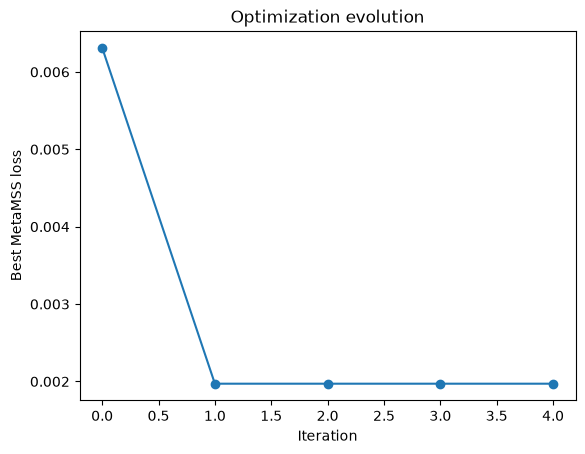

In [7]:
# Plotting the evolution of the agents
plt.plot(model.best_by_iter, marker="o")
plt.title("Optimization evolution")
plt.xlabel("Iteration")
plt.ylabel("Best MetaMSS loss")
model.best_by_iter[-1]


In [8]:
# You have access to all tested models
# model.tested_models


In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import ARDRegression
from sysidentpy.general_estimators import NARX

xlag = ylag = 5

estimators = [
    (
        "NARX_KNeighborsRegressor",
        NARX(
            base_estimator=KNeighborsRegressor(),
            xlag=xlag,
            ylag=ylag,
            basis_function=basis_function,
        ),
    ),
    (
        "NARX_DecisionTreeRegressor",
        NARX(
            base_estimator=DecisionTreeRegressor(random_state=42),
            xlag=xlag,
            ylag=ylag,
            basis_function=basis_function,
        ),
    ),
    (
        "NARX_RandomForestRegressor",
        NARX(
            base_estimator=RandomForestRegressor(
                n_estimators=200, random_state=42
            ),
            xlag=xlag,
            ylag=ylag,
            basis_function=basis_function,
        ),
    ),
    (
        "NARX_Catboost",
        NARX(
            base_estimator=CatBoostRegressor(
                iterations=800,
                learning_rate=0.1,
                depth=8,
                random_seed=42,
                allow_writing_files=False,
            ),
            xlag=xlag,
            ylag=ylag,
            basis_function=basis_function,
            fit_params={"verbose": False},
        ),
    ),
    (
        "NARX_ARD",
        NARX(
            base_estimator=ARDRegression(),
            xlag=xlag,
            ylag=ylag,
            basis_function=basis_function,
        ),
    ),
    (
        "FROLS-Polynomial_NARX",
        FROLS(
            order_selection=True,
            n_info_values=50,
            ylag=ylag,
            xlag=xlag,
            basis_function=basis_function,
            info_criteria="bic",
            err_tol=None,
        ),
    ),
    (
        "MetaMSS",
        MetaMSS(
            norm=-2,
            xlag=xlag,
            ylag=ylag,
            estimator=estimator,
            maxiter=5,
            n_agents=15,
            loss_func="metamss_loss",
            basis_function=basis_function,
            random_state=42,
        ),
    ),
]


all_results = {}
for model_name, modelo in estimators:
    all_results["%s" % model_name] = []
    with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
        modelo.fit(X=x_train_scaled, y=y_train_scaled)
    yhat_scaled = modelo.predict(X=x_test_scaled, y=y_test_scaled)
    yhat = y_scaler.inverse_transform(yhat_scaled)
    start = modelo.max_lag
    result = root_relative_squared_error(y_test[start:], yhat[start:])
    all_results["%s" % model_name].append(result)
    print(model_name, "%.3f" % np.mean(result))


NARX_KNeighborsRegressor 0.166
NARX_DecisionTreeRegressor 0.413


NARX_RandomForestRegressor 0.263


NARX_Catboost 0.104
NARX_ARD 0.074


FROLS-Polynomial_NARX 0.080


MetaMSS 0.031


In [10]:
for model_name, metric in sorted(
    all_results.items(), key=lambda x: np.mean(x[1]), reverse=False
):
    print(model_name, np.mean(metric))


MetaMSS 0.03135366827521778
NARX_ARD 0.07392748753107162
FROLS-Polynomial_NARX 0.08025565522199729
NARX_Catboost 0.1040535248536691
NARX_KNeighborsRegressor 0.16587519176849697
NARX_RandomForestRegressor 0.26295891414593836
NARX_DecisionTreeRegressor 0.41321720203965523
